### RainForest 모델

### 0. 데이터 로드
고객 이탈(churn) 예측 모델을 학습시키기 전, 미리 전처리해둔 데이터를 불러오는 준비

- 폴더에서 학습용(train)과 검증용(val) 데이터를 불러옴
- 테스트 데이터는 불러오지 않음. 최종평가에 사용할 예정
- 이전에 사용해둔 전처리기를 다시 불러옴. 학습 데이터에 사용했던 것과 똑같은 변환을 나중에 새 데이터에서도 적용하기 위함
- 데이터 크기와 이탈율을 출력해서 확인

In [1]:
import pandas as pd
import pickle
from pathlib import Path

# 노트북 실행 위치에 관계없이 프로젝트 루트의 data 폴더를 찾음
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "preprocessed").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("data/preprocessed 폴더를 찾을 수 없음")
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "preprocessed"

# Train / Val만 로드 (Test는 최종 평가 전용이라 제외)
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]

X_val = pd.read_csv(DATA_DIR / "X_val.csv")
y_val = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

with open(DATA_DIR / "preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))


X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


### 1. 랜덤포레스트 모델 학습 및 채점

- 랜덤 포레스트 분류기를 설정
- - 결정 트리 300개 설정, 트리 깊이 자유
- - 이탈 고객이 소수라서 생기는 불균형 보정, 이탈사례에 더 가중치
- 모델 학습 후, 모델이 처음 보는 검증 데이터의 이탈 여부를 예측
- 에측과 실제 정답을 비교해 accuracy, precision, recall
- 세 가지 점수를 출력
- 마지막 코드로 표 출력

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report
from sklearn import set_config

#CP949 문제 해결
set_config(display='text')

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
pred = model.predict(X_val)

print("Accuracy :", accuracy_score(y_val, pred))
print("Precision:", precision_score(y_val, pred))
print("Recall   :", recall_score(y_val, pred))
print()
print(classification_report(y_val, pred))


Accuracy : 0.6747685185185185
Precision: 0.665158371040724
Recall   : 0.6885245901639344

              precision    recall  f1-score   support

           0       0.68      0.66      0.67       437
           1       0.67      0.69      0.68       427

    accuracy                           0.67       864
   macro avg       0.67      0.67      0.67       864
weighted avg       0.68      0.67      0.67       864



### 2. 피드백

- 학습된 모델에게 "어떤 특성이 이탈 예측에 가장 중요했는지" 질문
- 특성 중요도를 꺼낸 후, 특성 이름을 붙여 짝지어줌
- 중요도가 높은 순으로 정렬해 출력

In [3]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)


avg_days_between_orders    0.200359
net_revenue                0.189699
recency_days               0.168440
distinct_products          0.148005
tenure_days                0.127954
frequency                  0.080408
recent_activity_ratio      0.045944
has_return                 0.016503
is_low_value               0.011866
is_uk                      0.010823
dtype: float64

### 3. 그리드 서치

- 하이퍼 파라미터 조합을 전부 시험 ( 총 81개 조합 )
- 81개 조합 각각에 대해 학습 반복
- 모든 조합이 끝나면 accuracy 기준으로 정렬, 1등 조합을 선정

In [4]:
import itertools
from sklearn.metrics import accuracy_score, precision_score, recall_score

param_grid = {
    'n_estimators': [300, 500, 800],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

keys = list(param_grid.keys())
combinations = list(itertools.product(*param_grid.values()))

results = []

for combo in combinations:
    params = dict(zip(keys, combo))
    model = RandomForestClassifier(
        **params,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    prec = precision_score(y_val, pred)
    rec = recall_score(y_val, pred)

    results.append({**params, 'accuracy': acc, 'precision': prec, 'recall': rec})
    print(params)
    print(f"Accuracy : {acc}")
    print(f"Precision: {prec}")
    print(f"Recall   : {rec}\n")

# 정렬해서 best 확인
results_sorted = sorted(results, key=lambda x: x['accuracy'], reverse=True)
best = results_sorted[0]
print("BEST:", best)

{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1}
Accuracy : 0.6886574074074074
Precision: 0.6740088105726872
Recall   : 0.7166276346604216

{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2}
Accuracy : 0.6921296296296297
Precision: 0.680089485458613
Recall   : 0.711943793911007

{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4}
Accuracy : 0.6909722222222222
Precision: 0.6769911504424779
Recall   : 0.7166276346604216

{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 1}
Accuracy : 0.6898148148148148
Precision: 0.6754966887417219
Recall   : 0.7166276346604216

{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2}
Accuracy : 0.6932870370370371
Precision: 0.6776315789473685
Recall   : 0.7236533957845434

{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 4}
Accuracy : 0.6909722222222222
P

### 4. 그리드 서치 시각화

- 파라미터 개별 그래프를 하나씩 골라 loss를 평균 내서 그래프로 그림
- - 선이 평평 : 파라이머는 성능에 별 영향이 없음
- - 뚜렷하게 기울기 : 중요한 파라미터
- 트리 개수 x 최대 깊이의 9개 조합 각각의 평균 loss를 그림
- 최적 조합 출력 : loss가 가장 낮은 행을 찾아 출력

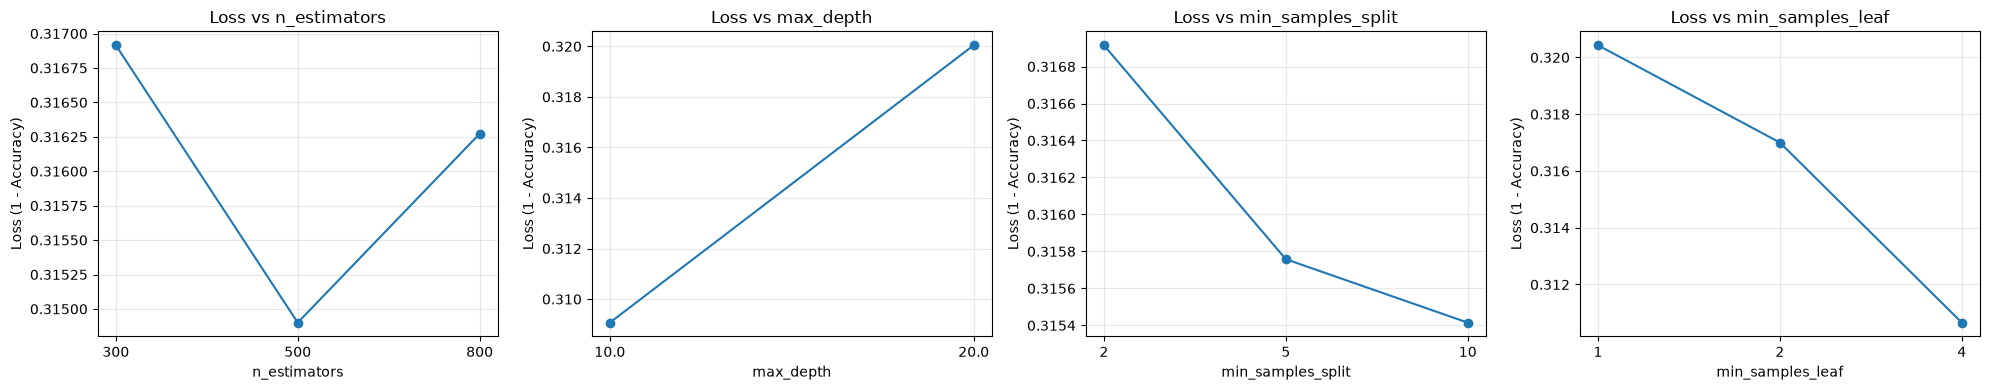

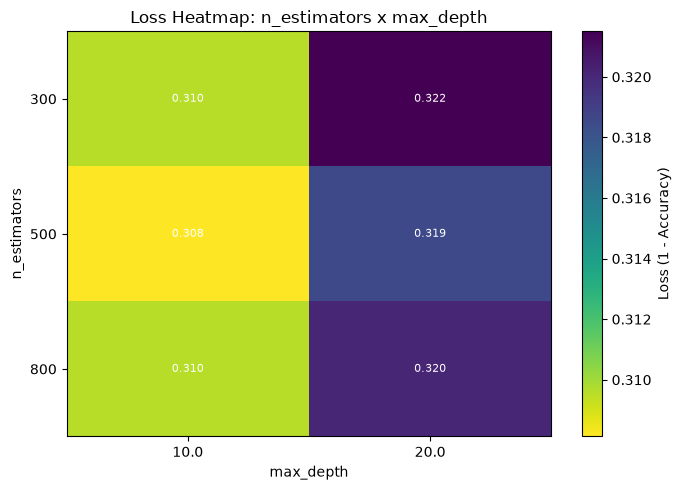

최적 조합 (loss 최소):
n_estimators         500.000000
max_depth             10.000000
min_samples_split     10.000000
min_samples_leaf       2.000000
accuracy               0.695602
precision              0.682222
recall                 0.718970
loss                   0.304398
Name: 34, dtype: float64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# results: 이전 그리드서치 for문에서 만든 리스트
# [{'n_estimators':.., 'max_depth':.., 'min_samples_split':.., 'min_samples_leaf':..,
#   'accuracy':.., 'precision':.., 'recall':..}, ...]

df = pd.DataFrame(results)
df['loss'] = 1 - df['accuracy']   # loss = 1 - accuracy

param_cols = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']

# 1) 파라미터별 주변 효과(marginal effect): 다른 파라미터 값 평균내고 하나씩만 변화시켜서 loss 추이 확인
fig, axes = plt.subplots(1, len(param_cols), figsize=(5 * len(param_cols), 4))

for ax, col in zip(axes, param_cols):
    grouped = df.groupby(col)['loss'].mean().reset_index()
    ax.plot(grouped[col].astype(str), grouped['loss'], marker='o')
    ax.set_title(f'Loss vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Loss (1 - Accuracy)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_vs_each_param.png', dpi=150)
plt.show()

# 2) 두 파라미터 조합에 대한 히트맵 (예: n_estimators x max_depth), 나머지는 평균
pivot = df.pivot_table(
    index='n_estimators',
    columns='max_depth',
    values='loss',
    aggfunc='mean'
)

plt.figure(figsize=(7, 5))
im = plt.imshow(pivot.values, cmap='viridis_r', aspect='auto')
plt.colorbar(im, label='Loss (1 - Accuracy)')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('max_depth')
plt.ylabel('n_estimators')
plt.title('Loss Heatmap: n_estimators x max_depth')

# 값 표시
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not pd.isna(val):
            plt.text(j, i, f'{val:.3f}', ha='center', va='center', color='white', fontsize=8)

plt.tight_layout()
plt.savefig('loss_heatmap.png', dpi=150)
plt.show()

# 3) loss가 가장 낮은 조합 확인
best_row = df.loc[df['loss'].idxmin()]
print("최적 조합 (loss 최소):")
print(best_row)

### 5. 최종 모델 저장 (joblib)

그리드서치 best 파라미터로 재학습한 모델을 `models/lsy/model_final.joblib`으로 저장한다.
비교 노트북(12번)이 이 파일을 자동으로 로드해서 다른 팀원 모델과 비교한다.

- 모델 객체만 저장 (dict로 감싸지 않기)
- 공용 X_val을 그대로 넣어 `predict_proba`가 동작하는지 저장 전 자가검증

In [7]:
import joblib

# 그리드서치 best 파라미터로 재학습
best_params = {k: best[k] for k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']}
print("best_params:", best_params)

final_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
final_model.fit(X_train, y_train)

# 저장 전 자가검증: 공용 X_val로 predict_proba 동작 확인
proba = final_model.predict_proba(X_val)[:, 1]
pred = (proba >= 0.5).astype(int)
print("Val Recall   :", round(recall_score(y_val, pred), 4))
print("Val Precision:", round(precision_score(y_val, pred), 4))

# 저장
SAVE_PATH = PROJECT_ROOT / "models" / "lsy" / "model_final.joblib"
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, SAVE_PATH)
print("저장 완료:", SAVE_PATH)

best_params: {'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 2}
Val Recall   : 0.719
Val Precision: 0.6822
저장 완료: D:\SKN_AI\Project2\models\lsy\model_final.joblib
